
HackBio Stage Two

Reproduce a single-cell analysis pipleine using Scanpy and Anndata
Dataset is BoneMarrow.h5ad.

INSTALLATION OF TOOLS:
Scanpy
Anndata
igraph
Celltypist
Decoupler


In [ ]:
!pip install scanpy
!pip install anndata
!pip install igraph
!pip install celltypist
!pip install decoupler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 45.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 88.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.9/120.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━

LOADING OF DATA

In [ ]:
# import core tools
import scanpy as sc
import anndata as ad

In [ ]:
!wget https://media.githubusercontent.com/media/josoga2/sc/refs/heads/main/bone_marrow.h5ad

--2025-12-03 13:24:24--  https://media.githubusercontent.com/media/josoga2/sc/refs/heads/main/bone_marrow.h5ad
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 354509549 (338M) [application/octet-stream]
Saving to: ‘bone_marrow.h5ad’

bone_marrow.h5ad    100%[===================>] 338.09M  20.7MB/s    in 15s     

2025-12-03 13:24:40 (22.4 MB/s) - ‘bone_marrow.h5ad’ saved [354509549/354509549]



In [ ]:
bone_marrow_adata = sc.read('bone_marrow.h5ad')

In [ ]:
print(bone_marrow_adata)

AnnData object with n_obs × n_vars = 14783 × 17374
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'doi', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_tsne', 'X_umap'


In [ ]:
bone_marrow_adata.shape

(14783, 17374)

In [ ]:
bone_marrow_adata.var.head()

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000161920,927,False,MED11,NCBITaxon:9606,gene,754,protein_coding
ENSG00000122335,429,False,SERAC1,NCBITaxon:9606,gene,2683,protein_coding
ENSG00000175548,149,False,ALG10B,NCBITaxon:9606,gene,1773,protein_coding
ENSG00000100330,426,False,MTMR3,NCBITaxon:9606,gene,634,protein_coding
ENSG00000176340,7171,False,COX8A,NCBITaxon:9606,gene,494,protein_coding


In [ ]:
bone_marrow_adata.obs.head()

,disease stage,treatment,timepoint,Dataset,sample,disease_original,disease_general,COVID-19 Condition,Lineage,Cell.group,...,is_primary_data,suspension_type,tissue_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep2,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Myeloid,CD14+ Monocyte,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,2P)e%zgsv_
Guo-AAACCTGAGAGGTTGC-7,remission,400 mg Tocilizumab at day 1,day 7,Guo et al._Nature Communication,Guo_P2-day7,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD8+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,78-year-old stage,Lv&N1yD6*0
Guo-AAACCTGAGATACACA-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,DZ>`^5OH2o
Guo-AAACCTGAGCGATTCT-1,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep1,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Lymphoid_T/NK,CD8+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,J4$QmqEgvX
Guo-AAACCTGAGTGAAGAG-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,Y&7u#&E`-T


In [ ]:
# Assign to DataFrame
bone_marrow_adata.to_df()

,ENSG00000161920,ENSG00000122335,ENSG00000175548,ENSG00000100330,ENSG00000176340,ENSG00000179846,ENSG00000204860,ENSG00000172260,ENSG00000141424,ENSG00000164512,...,ENSG00000164114,ENSG00000151702,ENSG00000224578,ENSG00000138756,ENSG00000111052,ENSG00000176946,ENSG00000150456,ENSG00000284934,ENSG00000261842,ENSG00000260456
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,0.0,0.000000,0.0,0.0,9.436466,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGAGGTTGC-7,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,8.817776,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGATACACA-3,0.0,8.651494,0.0,0.0,8.651494,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGCGATTCT-1,0.0,0.000000,0.0,0.0,8.858533,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGTGAAGAG-3,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Guo-TTTGTCAGTTTCGCTC-4,0.0,0.000000,0.0,0.0,8.389465,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-TTTGTCATCAGAGACG-7,0.0,0.000000,0.0,0.0,9.931639,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-TTTGTCATCAGATAAG-4,0.0,0.000000,0.0,0.0,10.009642,0.0,0.0,0.0,0.000000,0.0,...,0.0,9.01104,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


QUALITY CONTROL: To keep high quality cells and informative genes

In [ ]:
# Quality control of genes and cells
bone_marrow_adata.var_names_make_unique()
bone_marrow_adata.obs_names_make_unique()

In [ ]:
bone_marrow_adata.var['MT'] = bone_marrow_adata.var['feature_name'].str.startswith('MT-')
bone_marrow_adata.var['RIBO'] = bone_marrow_adata.var['feature_name'].str.startswith(('RPS', 'RPL'))
bone_marrow_adata.var['HB'] = bone_marrow_adata.var['feature_name'].str.contains('^HB[^(P)]', regex=True)

In [ ]:
mt_genes = bone_marrow_adata.var[bone_marrow_adata.var['MT']]
mt_genes

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,MT,RIBO,HB
ENSG00000228253,2270,False,MT-ATP8,NCBITaxon:9606,gene,207,protein_coding,True,False,False
ENSG00000198899,15626,False,MT-ATP6,NCBITaxon:9606,gene,681,protein_coding,True,False,False
ENSG00000198763,15561,False,MT-ND2,NCBITaxon:9606,gene,1042,protein_coding,True,False,False
ENSG00000198886,15656,False,MT-ND4,NCBITaxon:9606,gene,1378,protein_coding,True,False,False
ENSG00000198804,15656,False,MT-CO1,NCBITaxon:9606,gene,1542,protein_coding,True,False,False
ENSG00000198695,4611,False,MT-ND6,NCBITaxon:9606,gene,525,protein_coding,True,False,False
ENSG00000212907,6575,False,MT-ND4L,NCBITaxon:9606,gene,297,protein_coding,True,False,False
ENSG00000198888,14520,False,MT-ND1,NCBITaxon:9606,gene,956,protein_coding,True,False,False
ENSG00000198712,15669,False,MT-CO2,NCBITaxon:9606,gene,684,protein_coding,True,False,False
ENSG00000198727,15393,False,MT-CYB,NCBITaxon:9606,gene,1141,protein_coding,True,False,False


In [ ]:
sc.pp.calculate_qc_metrics(
bone_marrow_adata, qc_vars=["MT", 'RIBO', 'HB'], inplace=True, log1p=True
)


In [ ]:
bone_marrow_adata.obs.head()

,disease stage,treatment,timepoint,Dataset,sample,disease_original,disease_general,COVID-19 Condition,Lineage,Cell.group,...,pct_counts_in_top_500_genes,total_counts_MT,log1p_total_counts_MT,pct_counts_MT,total_counts_RIBO,log1p_total_counts_RIBO,pct_counts_RIBO,total_counts_HB,log1p_total_counts_HB,pct_counts_HB
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep2,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Myeloid,CD14+ Monocyte,...,40.537370,138.356339,4.937034,1.154665,879.968079,6.781022,7.343850,0.000000,0.000000,0.000000
Guo-AAACCTGAGAGGTTGC-7,remission,400 mg Tocilizumab at day 1,day 7,Guo et al._Nature Communication,Guo_P2-day7,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD8+ T cell,...,57.850376,113.859787,4.743712,1.350507,914.212402,6.819156,10.843602,0.000000,0.000000,0.000000
Guo-AAACCTGAGATACACA-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,59.749640,125.068520,4.836825,1.543431,952.813843,6.860468,11.758374,18.301193,2.960167,0.225849
Guo-AAACCTGAGCGATTCT-1,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep1,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Lymphoid_T/NK,CD8+ T cell,...,56.156243,103.474380,4.648942,1.182754,924.013672,6.829809,10.561848,0.000000,0.000000,0.000000
Guo-AAACCTGAGTGAAGAG-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,100.000121,138.531082,4.938287,2.870118,850.272156,6.746732,17.616129,0.000000,0.000000,0.000000


In [ ]:
bone_marrow_adata.var.head()

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,MT,RIBO,HB,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
ENSG00000161920,927,False,MED11,NCBITaxon:9606,gene,754,protein_coding,False,False,False,885,0.502831,0.407351,94.013394,7433.353516,8.913867
ENSG00000122335,429,False,SERAC1,NCBITaxon:9606,gene,2683,protein_coding,False,False,False,405,0.231814,0.208488,97.260367,3426.911377,8.139707
ENSG00000175548,149,False,ALG10B,NCBITaxon:9606,gene,1773,protein_coding,False,False,False,142,0.082084,0.078889,99.039437,1213.443970,7.102042
ENSG00000100330,426,False,MTMR3,NCBITaxon:9606,gene,634,protein_coding,False,False,False,404,0.227307,0.204822,97.267131,3360.278564,8.120077
ENSG00000176340,7171,False,COX8A,NCBITaxon:9606,gene,494,protein_coding,False,False,False,6898,4.277597,1.663471,53.338294,63235.750000,11.054641


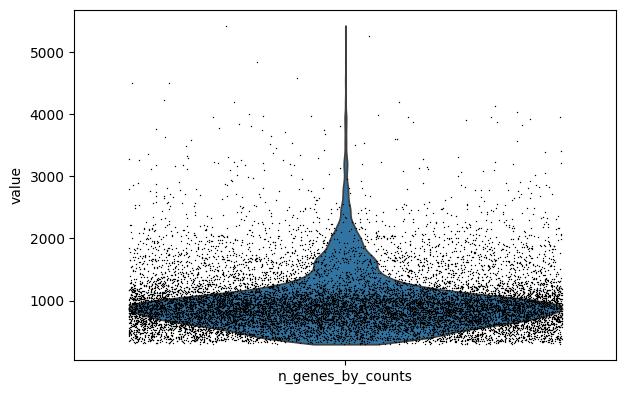

In [ ]:
# number of genes in cells
sc.pl.violin(
    bone_marrow_adata,
    ["n_genes_by_counts"],
    jitter=0.4,
    multi_panel=False,
)

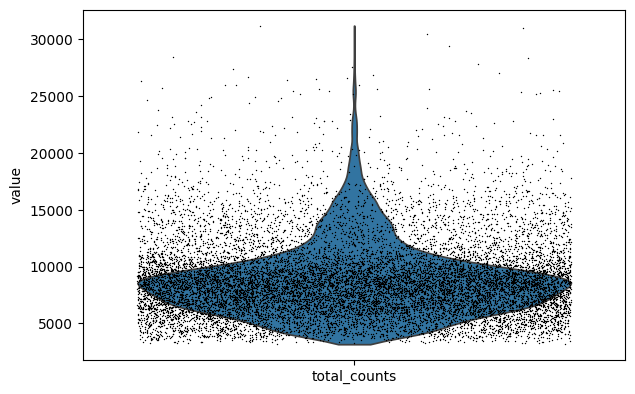

In [ ]:
# Total counts of genes
sc.pl.violin(
    bone_marrow_adata,
    ["total_counts"],
    jitter=0.4,
    multi_panel=False,
)

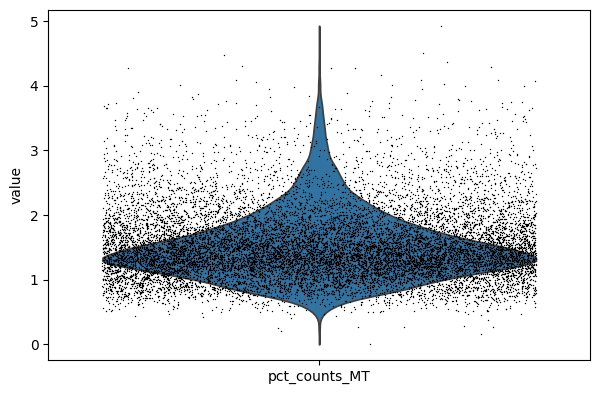

In [ ]:
# Mitochondrial genes
sc.pl.violin(
    bone_marrow_adata,
    ["pct_counts_MT"],
    jitter=0.4,
    multi_panel=False,
)

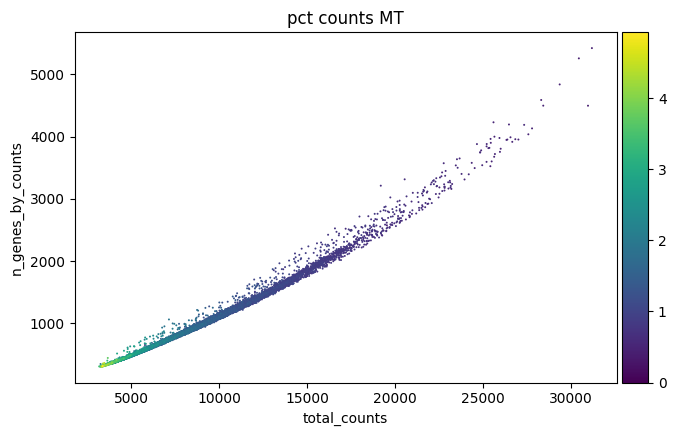

In [ ]:
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color="pct_counts_MT")

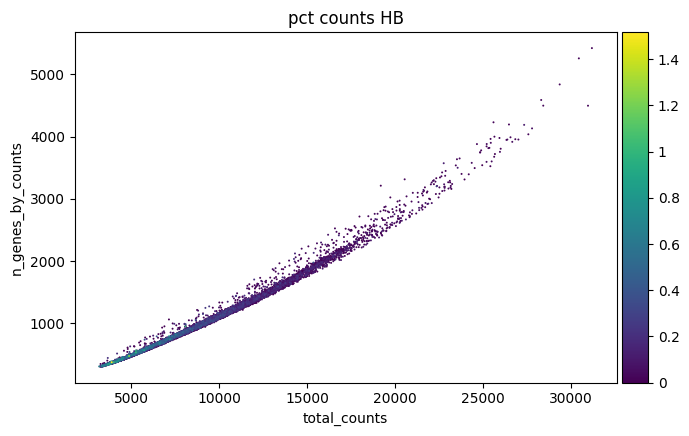

In [ ]:
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color="pct_counts_HB")

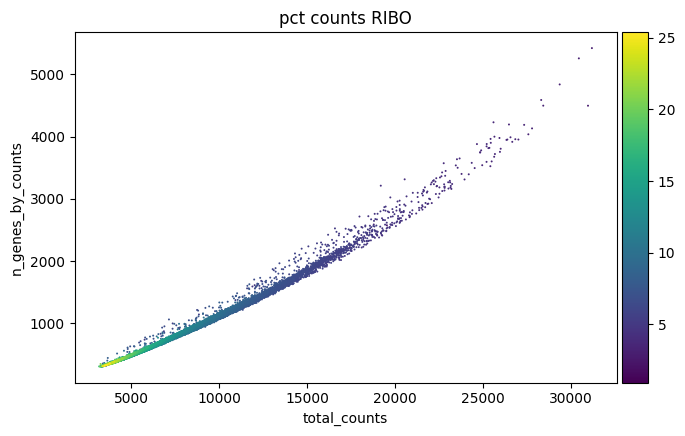

In [ ]:
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color="pct_counts_RIBO")

In [ ]:
bone_marrow_adata = bone_marrow_adata[
    bone_marrow_adata.obs['pct_counts_RIBO'] < 10,
    :
]

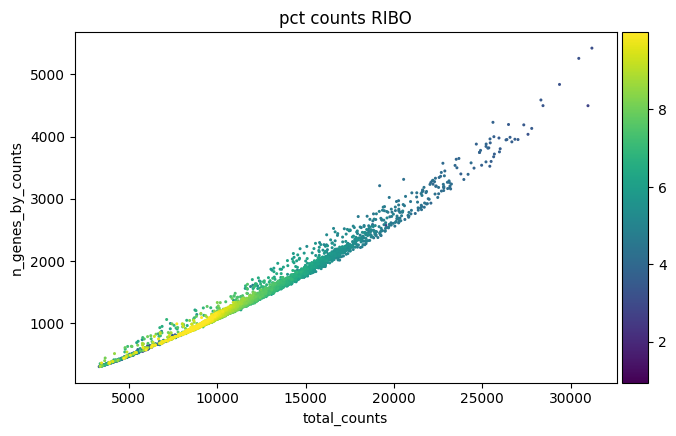

In [ ]:
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color = "pct_counts_RIBO")

In [ ]:
# Filtration of cells and genes
sc.pp.filter_cells(bone_marrow_adata, min_genes=1000)
sc.pp.filter_genes(bone_marrow_adata, min_cells=1000)

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


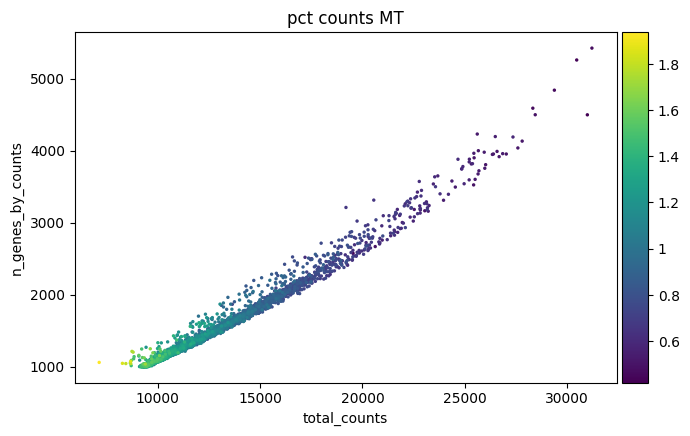

In [ ]:
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color="pct_counts_MT")

In [ ]:
sc.pp.scrublet(bone_marrow_adata) #doublet detection

NORMALIZATION

In [ ]:
bone_marrow_adata.layers["counts"] = bone_marrow_adata.X.copy()


In [ ]:
# Normalizing to median total counts
sc.pp.normalize_total(bone_marrow_adata)
# Logarithmize the data
sc.pp.log1p(bone_marrow_adata)

In [ ]:
sc.pp.highly_variable_genes(bone_marrow_adata)

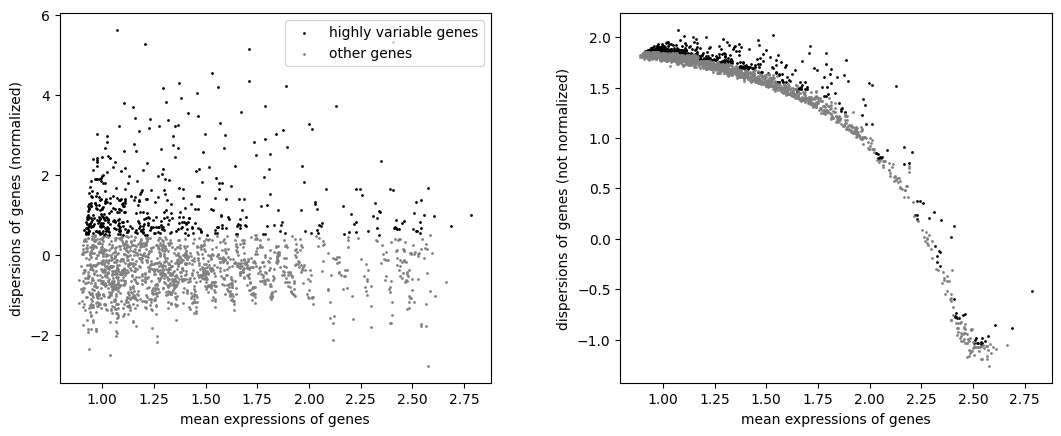

In [ ]:
sc.pl.highly_variable_genes(bone_marrow_adata )

Dimensionality Reduction: Principal Component Analysis, UMAP. Non Linear Dimensionality Reduction: Leiden

In [ ]:
# Principal Component Analysis
sc.tl.pca(bone_marrow_adata)

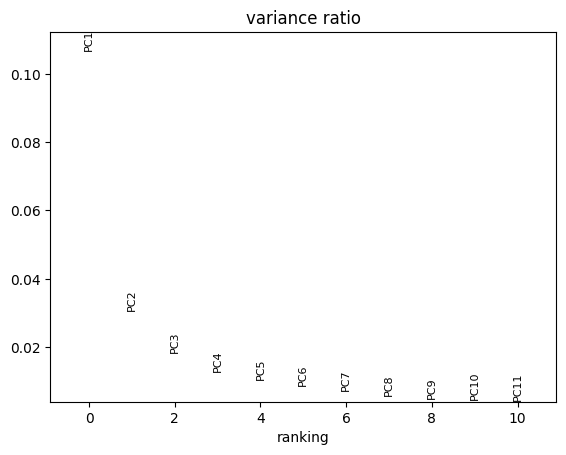

In [ ]:
sc.pl.pca_variance_ratio(bone_marrow_adata, n_pcs=10, log=False)

In [ ]:
sc.pp.neighbors(bone_marrow_adata)

In [ ]:
sc.tl.umap(bone_marrow_adata)

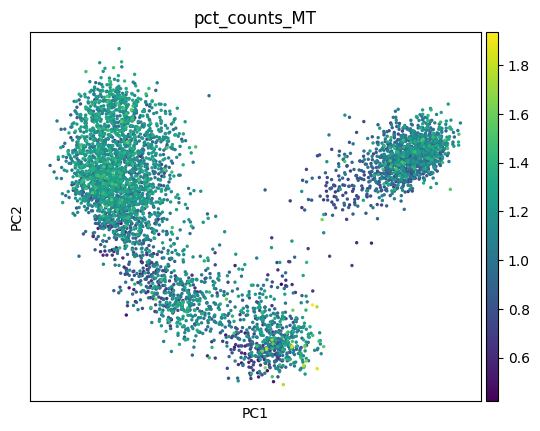

In [ ]:
sc.pl.pca(
    bone_marrow_adata,
    color=["pct_counts_MT"]
)

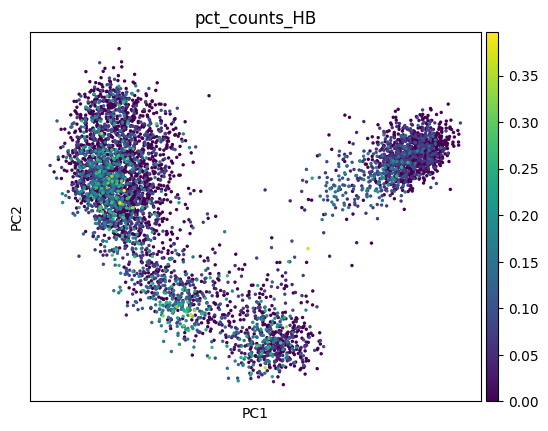

In [ ]:
sc.pl.pca(
    bone_marrow_adata,
    color=["pct_counts_HB"]
)

In [ ]:
sc.pp.neighbors(bone_marrow_adata)

In [ ]:
sc.tl.umap(bone_marrow_adata)

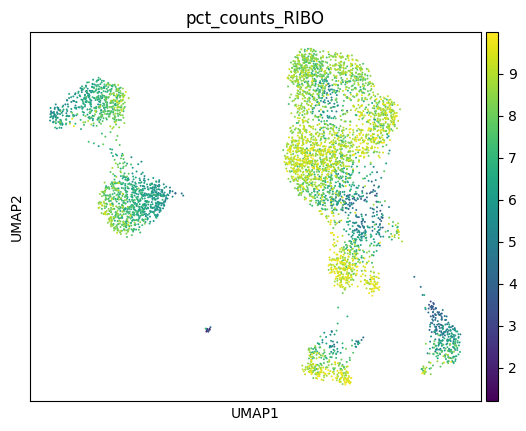

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["pct_counts_RIBO"],
    size=8,
)

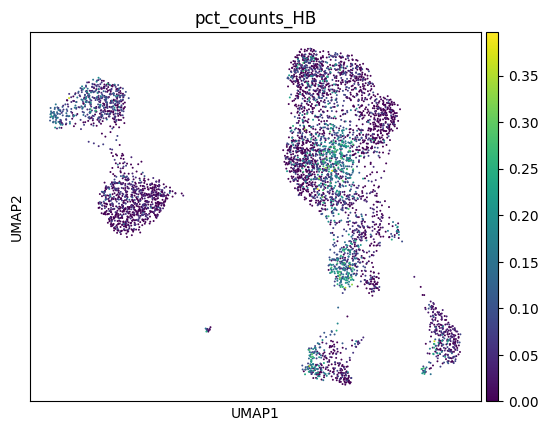

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["pct_counts_HB"],
    size=8,
)

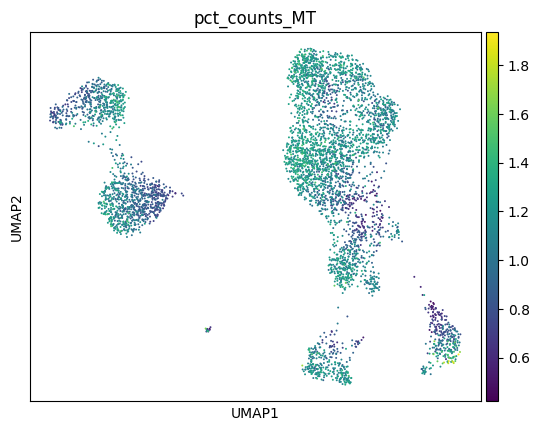

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["pct_counts_MT"],
    size=8,
)

In [ ]:
sc.tl.leiden(bone_marrow_adata, flavor="igraph", n_iterations=2)

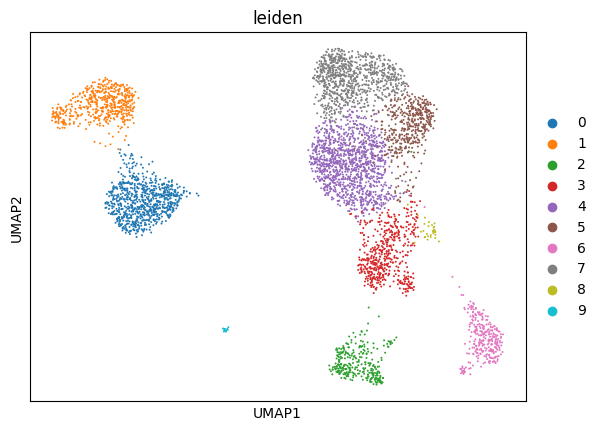

In [ ]:
# Cell clustering
sc.pl.umap(
    bone_marrow_adata,
    color=["leiden"],
    size=8,
)


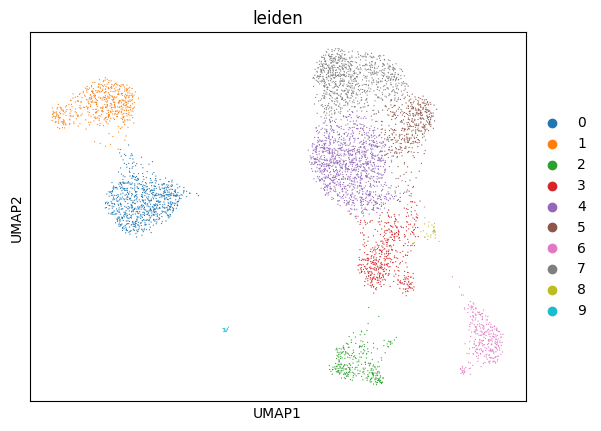

In [ ]:

sc.pl.umap(
    bone_marrow_adata,
    color=["leiden"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    ncols = 1
)

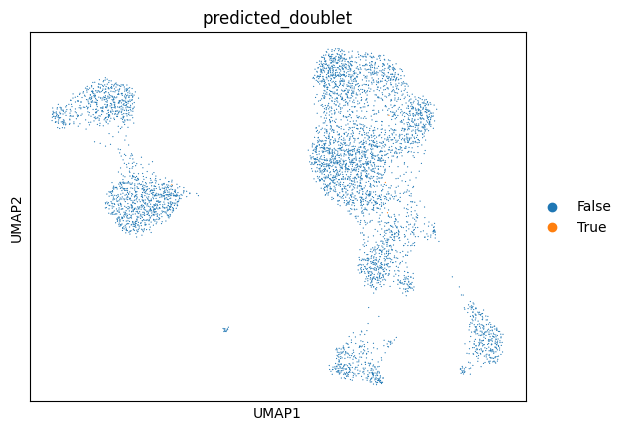

In [ ]:
# Doublet
sc.pl.umap(
    bone_marrow_adata,
    color=["predicted_doublet"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    ncols = 1
)

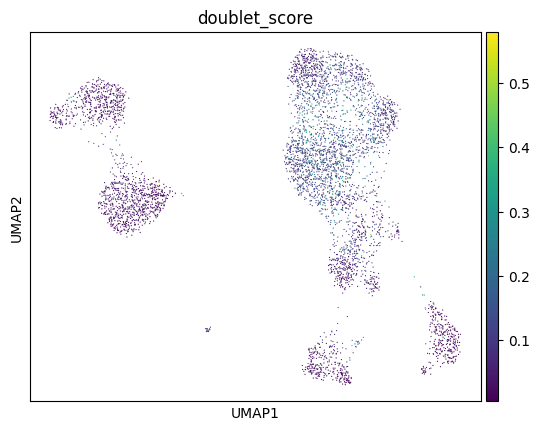

In [ ]:
# UMAP of Doublet
sc.pl.umap(
    bone_marrow_adata,
    color=[ "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    ncols = 1
)

In [ ]:
sc.tl.leiden(bone_marrow_adata, flavor="igraph", n_iterations=2, key_added="leiden_res0_02", resolution=0.02)
sc.tl.leiden(bone_marrow_adata, flavor="igraph", n_iterations=2, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(bone_marrow_adata, flavor="igraph", n_iterations=2, key_added="leiden_res2", resolution=2)

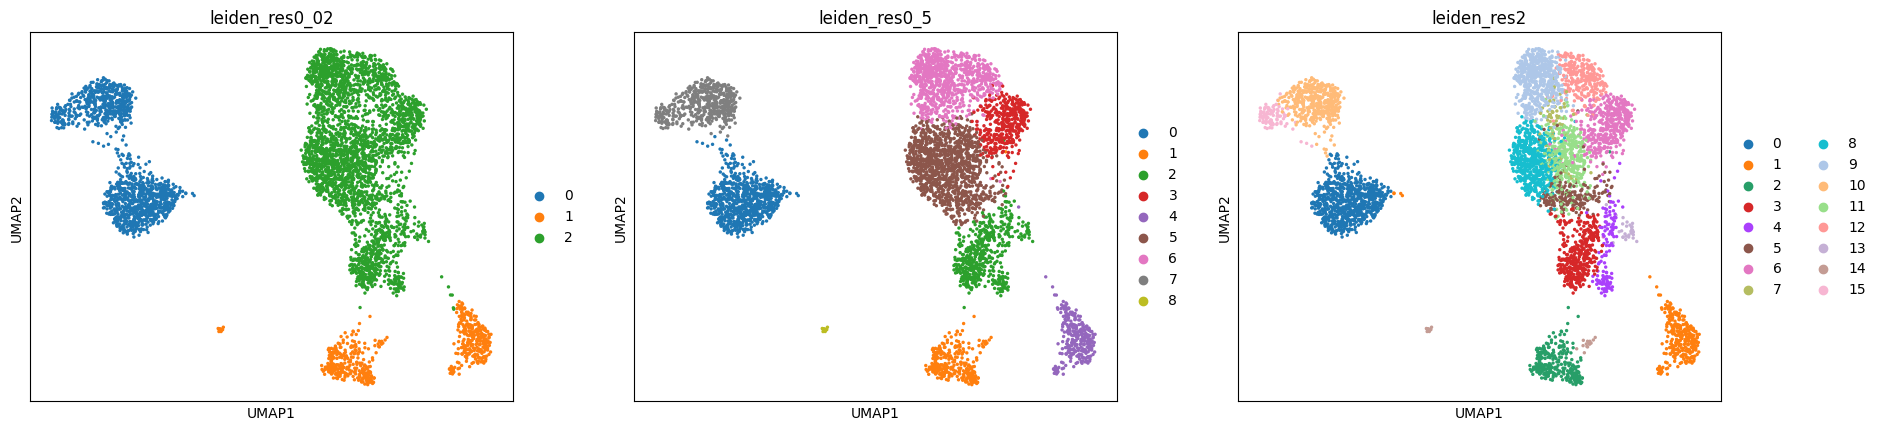

In [ ]:
# Clustering at resolutions of 0.02, 0.5, and 2
sc.pl.umap(
    bone_marrow_adata,
    color=["leiden_res0_02", "leiden_res0_5", "leiden_res2"],
)

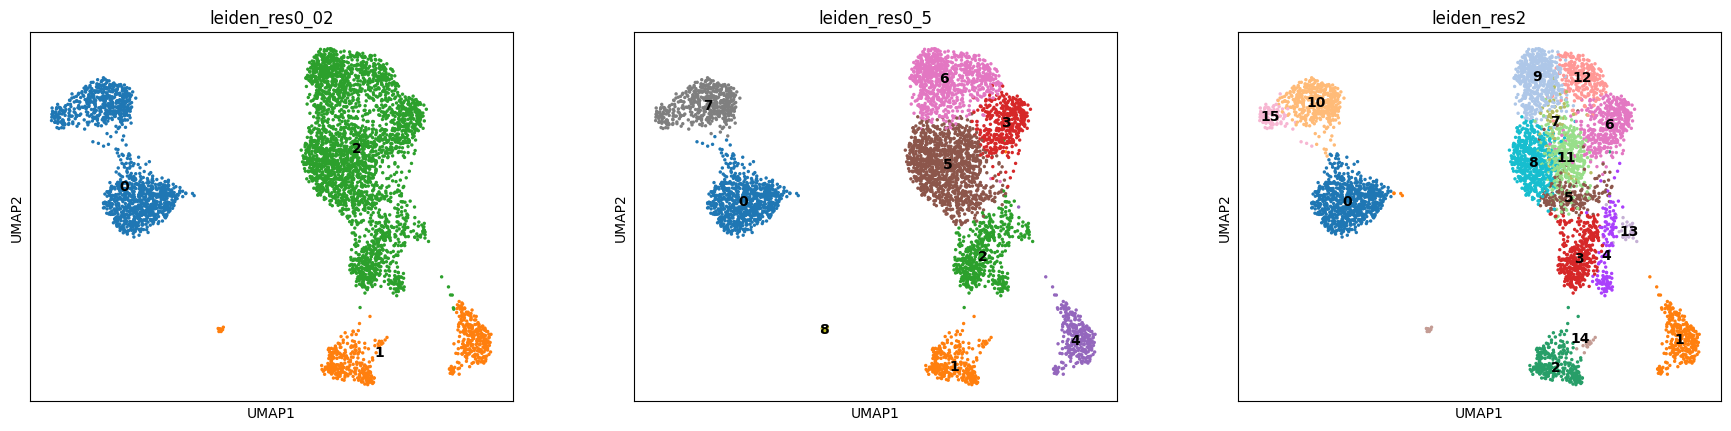

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["leiden_res0_02", "leiden_res0_5", "leiden_res2"],
    legend_loc="on data"
)

Cell Type Annotation

In [ ]:
import pandas as pd
import celltypist as ct
import decoupler as dc

/usr/local/lib/python3.12/dist-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [ ]:
!wget wget -O result.txt 'http://www.ensembl.org/biomart/martservice?query=<?xml version="1.0" encoding="UTF-8"?><!DOCTYPE Query><Query  virtualSchemaName = "default" formatter = "CSV" header = "0" uniqueRows = "0" count = "" datasetConfigVersion = "0.6" ><Dataset name = "hsapiens_gene_ensembl" interface = "default" ><Attribute name = "ensembl_gene_id" /><Attribute name = "external_gene_name" /></Dataset></Query>'
#this downloads the table of genes directly from ensemble

--2025-12-03 13:27:49--  http://wget/
Resolving wget (wget)... failed: Name or service not known.
wget: unable to resolve host address ‘wget’
--2025-12-03 13:27:49--  http://www.ensembl.org/biomart/martservice?query=%3C?xml%20version=%221.0%22%20encoding=%22UTF-8%22?%3E%3C!DOCTYPE%20Query%3E%3CQuery%20%20virtualSchemaName%20=%20%22default%22%20formatter%20=%20%22CSV%22%20header%20=%20%220%22%20uniqueRows%20=%20%220%22%20count%20=%20%22%22%20datasetConfigVersion%20=%20%220.6%22%20%3E%3CDataset%20name%20=%20%22hsapiens_gene_ensembl%22%20interface%20=%20%22default%22%20%3E%3CAttribute%20name%20=%20%22ensembl_gene_id%22%20/%3E%3CAttribute%20name%20=%20%22external_gene_name%22%20/%3E%3C/Dataset%3E%3C/Query%3E
Resolving www.ensembl.org (www.ensembl.org)... 193.62.193.83
Connecting to www.ensembl.org (www.ensembl.org)|193.62.193.83|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘result.txt’

result.txt              [        <=>    

In [ ]:
ensembl_var = pd.read_csv('result.txt', header = None)

ensembl_var.columns = ['ensembl_gene_id', 'gene_name']

ensembl_var.head()

,ensembl_gene_id,gene_name
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [ ]:
# Query Omnipath and get PanglaoDB
markers = dc.op.resource(name="PanglaoDB", organism="human")

# Keep canonical cell type markers alone
markers = markers[markers["canonical_marker"]]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

#Format because dc only accepts cell_type and genesymbol
markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]
markers.head()

,source,target
,,
2,Bergmann glia,A2M
4,Mast cells,A4GALT
5,Embryonic stem cells,A7KBS4
8,Pinealocytes,AANAT
9,Astrocytes,AANAT


In [ ]:
#correct target to ensemble
markers = markers.merge(ensembl_var, left_on="target", right_on="gene_name", how="left")
markers = markers.drop(columns=["target"])
# Remove duplicated entries
markers = markers[~markers.duplicated(["source", "ensembl_gene_id"])]

#Format because dc only accepts cell_type and genesymbol
markers = markers.rename(columns={"source": "source", "ensembl_gene_id": "target"})

markers = markers[["source", "target"]]
markers = markers.dropna()

markers.head()

,source,target
0,Bergmann glia,ENSG00000175899
1,Mast cells,ENSG00000128274
3,Pinealocytes,ENSG00000129673
4,Astrocytes,ENSG00000129673
5,Sertoli cells,ENSG00000205002


In [ ]:
dc.mt.ulm(data=bone_marrow_adata, net=markers, tmin=3)

In [ ]:
bone_marrow_adata.obsm["score_ulm"]

,Adipocytes,Astrocytes,B cells,B cells memory,B cells naive,Basophils,Bergmann glia,Cardiomyocytes,Chondrocytes,Dendritic cells,...,Plasmacytoid dendritic cells,Platelets,Podocytes,Satellite glial cells,Sebocytes,Sertoli cells,T cells,T helper cells,Thymocytes,Tuft cells
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,1.394355,0.231594,0.136460,-0.503890,0.028544,1.121389,0.395825,0.812309,1.483745,3.729776,...,-0.571249,0.802470,-1.470932,0.900116,0.862676,0.842347,-3.525913,-0.356782,-2.407312,1.171119
Guo-AAACCTGCACACCGCA-4,-1.445288,0.234181,3.194018,2.985831,3.977112,-0.614262,-0.387789,1.136322,-1.267920,1.889445,...,0.451081,-0.742661,-1.251170,-1.251170,-1.251170,-0.030758,-1.180203,1.136322,0.849319,0.035176
Guo-AAACCTGCATCCAACA-3,-0.370098,0.351149,-1.110148,0.099114,-0.473216,0.929723,-0.285013,-0.024119,-1.251129,-1.286104,...,-1.072786,-0.206910,0.055220,-1.209779,-1.209779,-1.209779,2.435220,0.099556,0.234370,0.022008
Guo-AAACCTGGTTCAGGCC-4,1.128119,-0.229604,-0.261212,0.658905,0.432993,-1.935547,0.301223,0.596291,-0.591325,1.052262,...,-1.001559,1.061779,-0.498485,-1.594176,-0.498485,-1.594176,1.638155,-0.498485,-0.591325,-0.525084
Guo-AAACCTGTCAAGGTAA-2,0.323622,-0.165212,1.716037,0.740557,0.449159,-1.004657,0.351156,0.820398,-0.348702,0.060995,...,-0.008648,0.618839,-1.507787,-0.331159,-0.384346,-1.507787,1.904652,0.820398,-0.286429,0.366527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Guo-TTTGTCAGTTCCGGCA-7,-0.536221,0.132522,-0.212545,-0.870591,0.331210,2.200868,2.581381,-0.175544,-1.467893,0.063233,...,-0.434150,1.370058,-0.175544,-1.330888,0.979441,-1.330888,2.713133,-0.175544,0.096852,-0.123854
Guo-TTTGTCAGTTCGTCTC-4,-1.564393,0.033237,0.965701,0.381627,1.429423,-0.772468,1.468783,0.996642,-0.067557,1.086967,...,0.223485,2.389233,-1.354247,-1.354247,-0.204161,-1.354247,2.963550,1.047776,-0.036229,1.517714
Guo-TTTGTCAGTTTCGCTC-4,-0.368934,1.273114,0.694045,1.489911,1.312309,-0.522302,0.743906,-0.022784,-0.490799,0.159958,...,-0.260363,1.307553,-1.209753,-1.209753,-1.209753,-0.022784,2.304299,-1.209753,0.205255,0.943003


In [ ]:
score = dc.pp.get_obsm(bone_marrow_adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 4973 × 49
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'total_counts_RIBO', 'log1p_total_counts_RIBO', 'pc

In [ ]:
bone_marrow_adata.obsm["score_ulm"].columns

Index(['Adipocytes', 'Astrocytes', 'B cells', 'B cells memory',
       'B cells naive', 'Basophils', 'Bergmann glia', 'Cardiomyocytes',
       'Chondrocytes', 'Dendritic cells', 'Embryonic stem cells',
       'Endothelial cells', 'Eosinophils', 'Erythroblasts',
       'Erythroid-like and erythroid precursor cells', 'Fibroblasts',
       'Gamma delta T cells', 'Germ cells', 'Hematopoietic stem cells',
       'Hepatocytes', 'Keratinocytes', 'Kupffer cells',
       'Luminal epithelial cells', 'Macrophages', 'Mast cells',
       'Megakaryocytes', 'Mesangial cells', 'Microfold cells', 'Microglia',
       'Monocytes', 'Müller cells', 'NK cells', 'Natural killer T cells',
       'Neurons', 'Neutrophils', 'Osteoclasts', 'Pancreatic progenitor cells',
       'Paneth cells', 'Plasma cells', 'Plasmacytoid dendritic cells',
       'Platelets', 'Podocytes', 'Satellite glial cells', 'Sebocytes',
       'Sertoli cells', 'T cells', 'T helper cells', 'Thymocytes',
       'Tuft cells'],
      dtype='obj

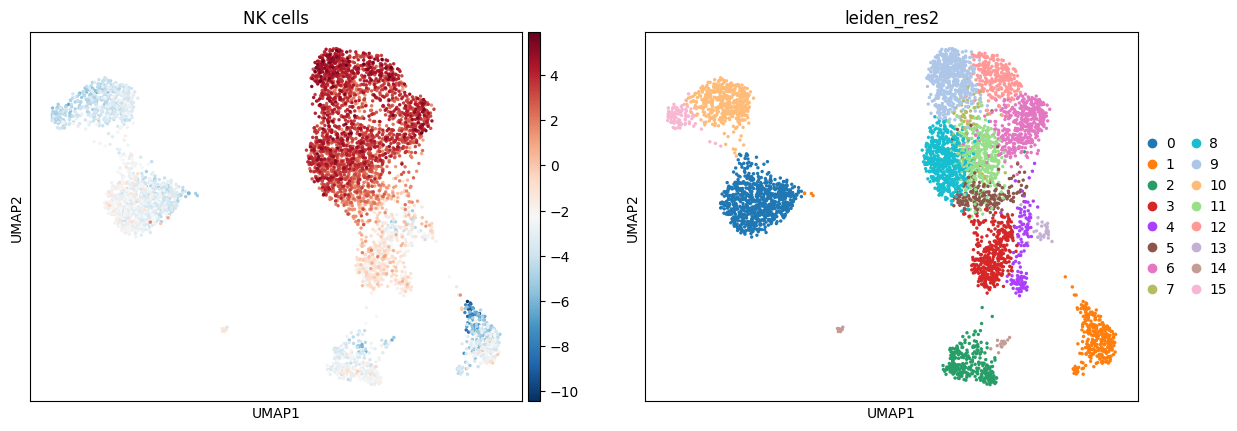

In [ ]:
# Natural Killer cells
sc.pl.umap(score,  color=["NK cells", "leiden_res2"], cmap="RdBu_r")

In [ ]:
import seaborn as sns

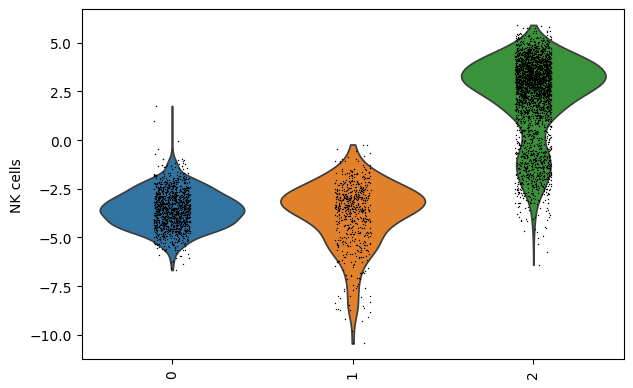

In [ ]:
sc.pl.violin(score, keys=["NK cells"], groupby="leiden_res0_02", rotation=90)

In [ ]:
bone_marrow_adata_rank = dc.tl.rankby_group(score, groupby="leiden_res0_5", reference="rest", method="t-test_overestim_var")
bone_marrow_adata_rank = bone_marrow_adata_rank[bone_marrow_adata_rank["stat"] > 0]
bone_marrow_adata_rank

,group,reference,name,stat,meanchange,pval,padj
0,0,rest,Neutrophils,52.833913,2.827973,0.000000e+00,0.000000e+00
1,0,rest,Dendritic cells,49.255123,2.970182,5.906547e-284,1.447104e-282
2,0,rest,Microglia,47.173618,2.294932,2.259981e-277,3.691302e-276
3,0,rest,Monocytes,43.080973,2.486823,2.366628e-243,2.899119e-242
4,0,rest,Satellite glial cells,36.045247,1.447426,2.475216e-208,2.425711e-207
...,...,...,...,...,...,...,...
431,8,rest,B cells memory,0.770326,0.291293,4.503357e-01,5.516612e-01
434,8,rest,Germ cells,0.499235,0.140037,6.227446e-01,7.096392e-01
438,8,rest,Plasma cells,0.239515,0.135632,8.128566e-01,8.474463e-01
439,8,rest,Neutrophils,0.171098,0.084919,8.660954e-01,8.841391e-01


In [ ]:
# Cluster Annotation
cluster_annotations = bone_marrow_adata_rank[bone_marrow_adata_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()


In [ ]:
cluster_annotations

{'0': 'Neutrophils',
 '1': 'B cells naive',
 '2': 'T cells',
 '3': 'Plasma cells',
 '4': 'Plasma cells',
 '5': 'T cells',
 '6': 'Gamma delta T cells',
 '7': 'Dendritic cells',
 '8': 'Platelets'}

In [ ]:
bone_marrow_adata.obs['cell_type'] = bone_marrow_adata.obs['leiden_res0_5'].map(cluster_annotations)

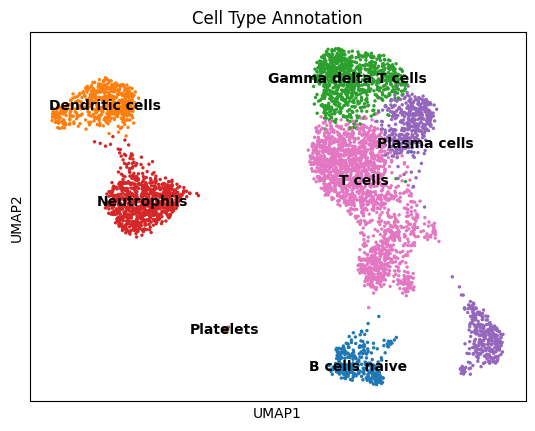

In [ ]:
sc.pl.umap(bone_marrow_adata, color='cell_type', legend_loc='on data', title='Cell Type Annotation')


In [ ]:
# Example of how to subset for multiple genes in the 'source' column
available_genes = set(bone_marrow_adata.var_names)

b_cell_markers = markers[markers['source'].isin(['B cells naive'])]['target']
b_cell_markers = b_cell_markers[b_cell_markers.isin(available_genes)]

t_cell_markers = markers[markers['source'].isin(['T cells'])]['target']
t_cell_markers = t_cell_markers[t_cell_markers.isin(available_genes)]

plasma_cells_markers = markers[markers['source'].isin(['Plasma cells'])]['target']
plasma_cells_markers = plasma_cells_markers[plasma_cells_markers.isin(available_genes)]

platelets_markers = markers[markers['source'].isin(['Platelets'])]['target']
platelets_markers = platelets_markers[platelets_markers.isin(available_genes)]

In [ ]:
marker_genes_dict = {
    "T cell": t_cell_markers.head().tolist(),
    "B cells naive": b_cell_markers.head().tolist(),
    "Platelets": platelets_markers.head().tolist(),
    "Plasma cells": plasma_cells_markers.head().tolist(),
}

categories: 0, 1, 2, etc.
var_group_labels: T cell, B cells naive, Platelets, etc.


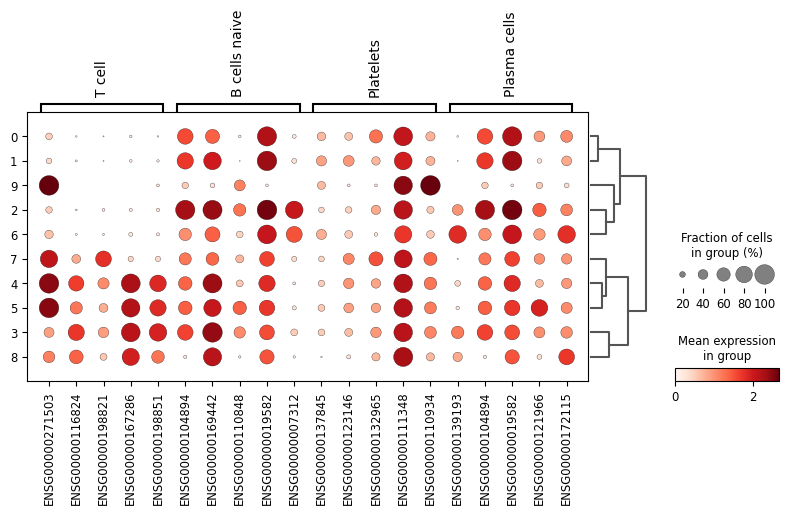

In [ ]:
# Generate the dot plot
sc.pl.dotplot(
    bone_marrow_adata,
    var_names=marker_genes_dict, # Use the dictionary for grouped genes
    groupby='leiden', # Or whatever column holds your cell clusters (e.g., 'clusters', 'cell_type')
    dendrogram=True, # Set to True if you want to cluster the genes/groups
    color_map='Reds',
    use_raw=False
)

categories: B cells naive, Dendritic cells, Gamma delta T cells, etc.
var_group_labels: T cell, B cells naive, Platelets, etc.


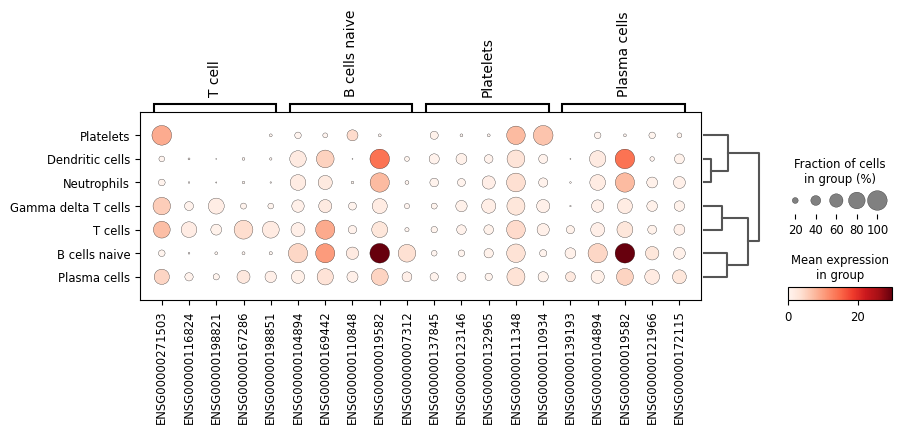

In [ ]:
sc.tl.dendrogram(bone_marrow_adata, groupby='cell_type')
sc.pl.dotplot(bone_marrow_adata, marker_genes_dict, "cell_type", dendrogram=True)

categories: 0, 1, 2, etc.
var_group_labels: T cell, B cells naive, Platelets, etc.


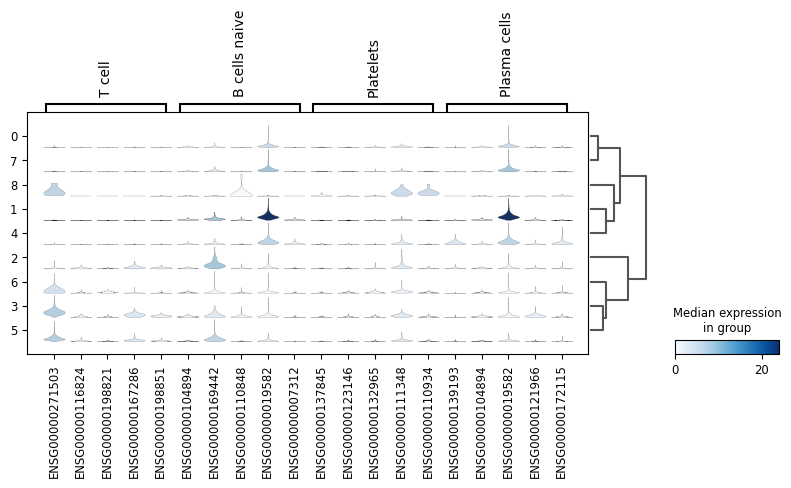

In [ ]:
sc.pl.stacked_violin(
    bone_marrow_adata, marker_genes_dict, groupby="leiden_res0_5",  dendrogram=True
)

categories: 0, 1, 2
var_group_labels: T cell, B cells naive, Platelets, etc.


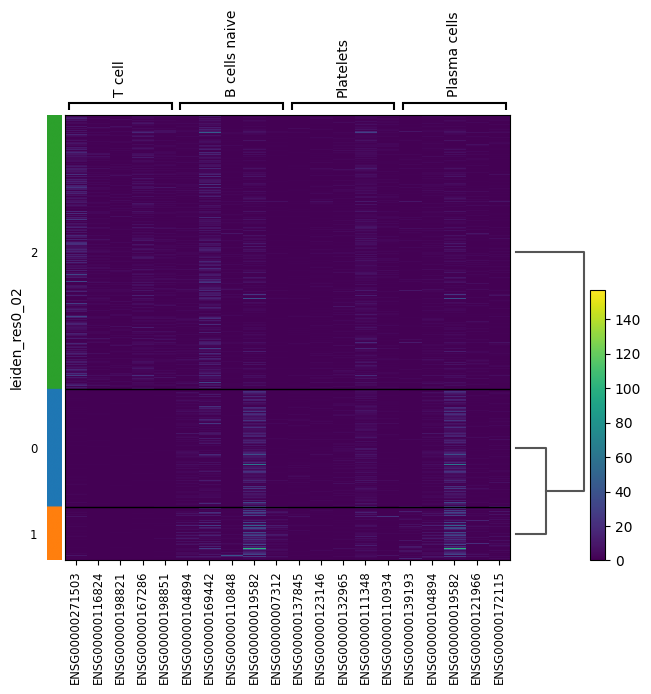

In [ ]:
sc.pl.heatmap(
    bone_marrow_adata, marker_genes_dict, groupby="leiden_res0_02", cmap="viridis", dendrogram=True
)

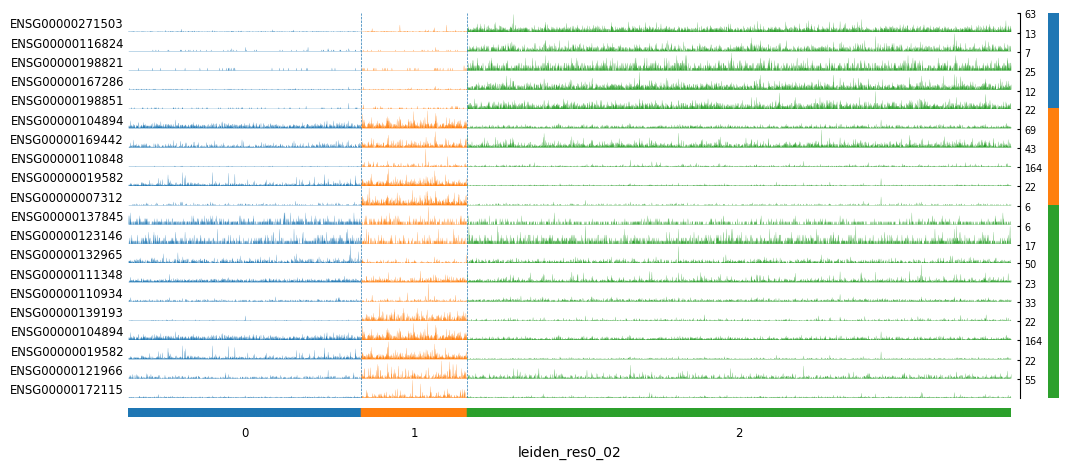

In [74]:
# Using genome tracks
sc.pl.tracksplot(bone_marrow_adata, marker_genes_dict, groupby="leiden_res0_02", dendrogram=False)

A.  What cell types did you identify?

 1. Neutrophils
 2. Plasma Cells
 3. Plaletes
 4. B cells Naive
 5. T cells
 6. Dendritic cells
 7. Gamma delta T cells



B. Explain the biological role of each cell type in Bone Marrow or peripheral immunity

1. Neutrophils: active phagocytes that release enzymes to eliminate bacteria

2. Plasma cells: differentiated B-lymophocytes which secretes immunoglobin or antibodies

3. Plaletes: discoid, anuecleate cells that help in clot blood

4. B cells naive:key regulating cells, responsible for antibody-mediated immunity

5. T cells: responsible for cell-mediated immunity

6. Dendritic cells:acquisition of antigens and stimulation of lymphocytes

7. Gamma delta T cell: bridges the innate and adaptive immune response


C. Is the tissue source really bone marrow? Justify your answer
Your job is to reason your way toward (or away from) that conclusion using:

Expected vs. missing lineage populations:
Erythroid Lineage
Megakaryocytic lineage
Hematopoietic stem and progenitor cells
Myeloic cells

Observed populations: T cells, B cells, Neutrophils, Dendritic cells, Plasma cells and Platelets.

Typical frequency distributions: Presence of Lymphocyte (T cells, B cells naive, Gamma delta T cells), Dendritic cells, Neutrophil, Moderate plasma cells, and low platelets.

Presence or absence of progenitors: There is absence of CD34+ progenitors, megakaryocytes, eythroid and endothelial cell, all of which are seen in bone marrow cells.

Conclusion: The dataset is not bone marrow but peripheral blood mononuclear cells (PBMC).
Based on the absence of hallmark bone-marrow lineages (erythroid and megakaryocytic cells), the lack of detectable hematopoietic stem/progenitor (CD34+/KIT+) signatures, and a cell composition dominated by mature lymphocytes (T/B/NK) plus expected PBMC contaminants (dendritic cells, neutrophil fragments, plasma cells, platelets), the most parsimonious and testable conclusion is that this dataset represents PBMC / a PBMC-like preparation, not an unsorted bone-marrow sample.

D. Based on the relative abundance of cell types, is the patient healthy or infected?

Neutrophils: Neutrophil is present but only a small fraction.

monocytes: No annotated monocyte clusters, however dendritic cell is present, which point to antigen activation.

NK cell activation states: No annotated NK cells, but gamma delta T cells are annotated and are moderately abundant

Lymphocyte depletion or expansion: Lymphocyte is expanded due to the relative abundance of the T cells and B cell cluster.

Conclusion: The patient present an active infection.   
Justification: Abundant plasma cells cluster, which indicate active infection. The t cells, b cells and gamma delta T cells are expanded but neutrophils are not, no monocyte cluster and presence of dendritic cells.